<a href="https://colab.research.google.com/github/eliseis/gbjhtygjhnfvbngfthyj/blob/main/word2vec_sgns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word2Vec (SGNS)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import zipfile
import urllib.request
from collections import Counter
from pathlib import Path

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

from IPython.display import clear_output


1. **Tokenization & Counting**: Building the frequency table.
2. **Subsampling**: Frequent words are probabilistically dropped to improve training speed and quality of rare word vectors.
   $$ P(keep) = 1 - \sqrt{\frac{t}{f(w)}} $$
3. **Noise Distribution**: For negative sampling, we draw from the unigram distribution raised to the power 0.75.
   $$ P_n(w) \propto U(w)^{0.75} $$


In [28]:
import numpy as np
from collections import Counter

class Vocabulary:
    def __init__(self, min_count=5, subsample_threshold=1e-5, noise_power=0.75, table_size=10**7):
        self.min_count = min_count
        self.subsample_threshold = subsample_threshold
        self.noise_power = noise_power
        self.table_size = table_size

        self.word2idx = {}
        self.idx2word = []
        self.subsample_probs = np.array([])
        self.unigram_table = np.array([], dtype=np.int32)

    @property
    def size(self):
        return len(self.idx2word)

    def build(self, tokens):
        raw_counts = Counter(tokens)
        total_words = sum(raw_counts.values())

        filtered = sorted(
            ((w, c) for w, c in raw_counts.items() if c >= self.min_count),
            key=lambda x: -x[1]
        )

        self.idx2word = [w for w, _ in filtered]
        self.word2idx = {w: i for i, w in enumerate(self.idx2word)}
        counts = np.array([c for _, c in filtered], dtype=np.float64)

        freq = counts / total_words
        self.subsample_probs = 1.0 - np.sqrt(self.subsample_threshold / (freq + 1e-12))
        self.subsample_probs = np.clip(self.subsample_probs, 0.0, 1.0)

        noise = counts ** self.noise_power
        noise_distribution = noise / noise.sum()
        self._build_unigram_table(noise_distribution)

        return self

    def _build_unigram_table(self, noise_distribution):
        self.unigram_table = np.zeros(self.table_size, dtype=np.int32)
        cumulative_probs = np.cumsum(noise_distribution)

        vocab_idx = 0
        for table_idx in range(self.table_size):
            while table_idx / self.table_size > cumulative_probs[vocab_idx]:
                vocab_idx += 1
                if vocab_idx >= self.size:
                    vocab_idx = self.size - 1
            self.unigram_table[table_idx] = vocab_idx

    def encode(self, tokens):
        return np.array([self.word2idx[t] for t in tokens if t in self.word2idx], dtype=np.int32)

    def subsample_mask(self, indices, rng):
        discard_probs = self.subsample_probs[indices]
        return rng.random(len(indices)) >= discard_probs

    def sample_negatives_fast(self, count, rng):
        random_indices = rng.integers(0, self.table_size, size=count)
        return self.unigram_table[random_indices]

## Model
$$J = - \left( \log \sigma(\mathbf{u}_o^\top \mathbf{v}_c) + \sum_{k=1}^K \log \sigma(-\mathbf{u}_{n_k}^\top \mathbf{v}_c) \right)$$

In [29]:
import time

class Word2VecSGNS:
    def __init__(self, vocab_size, embedding_dim, seed=42):
        self.V = vocab_size
        self.D = embedding_dim
        self.rng = np.random.default_rng(seed)

        self.W_in = (self.rng.random((vocab_size, embedding_dim)) - 0.5) / embedding_dim
        self.W_out = np.zeros((vocab_size, embedding_dim))
        self._cache = None

    @staticmethod
    def _sigmoid(x):
        x = np.asarray(x)
        out = np.empty_like(x, dtype=np.float64)
        pos = x >= 0
        out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
        exp_x = np.exp(x[~pos])
        out[~pos] = exp_x / (1.0 + exp_x)
        return out

    def forward(self, center, context, negatives):
        v_center = self.W_in[center]
        u_context = self.W_out[context]
        u_negative = self.W_out[negatives]

        pos_score = np.dot(v_center, u_context)
        pos_sigmoid = self._sigmoid(pos_score)

        neg_scores = np.dot(u_negative, v_center)
        neg_sigmoid = self._sigmoid(-neg_scores)

        eps = 1e-12
        loss = -(np.log(pos_sigmoid + eps) + np.sum(np.log(neg_sigmoid + eps)))

        self._cache = (center, context, negatives, v_center, u_context, u_negative, pos_sigmoid, neg_sigmoid)
        return loss

    def backward(self):
        center, context, negatives, v_center, u_context, u_negative, pos_sigmoid, neg_sigmoid = self._cache

        d_pos_score = pos_sigmoid - 1.0
        d_neg_score = 1.0 - neg_sigmoid

        d_u_context = d_pos_score * v_center
        d_u_negative = d_neg_score[:, np.newaxis] * v_center

        d_v_center = d_pos_score * u_context
        d_v_center += np.dot(d_neg_score, u_negative)

        return d_v_center, d_u_context, d_u_negative

    def update(self, lr):
        d_v_c, d_u_ctx, d_u_neg = self.backward()

        center = self._cache[0]
        context = self._cache[1]
        negatives = self._cache[2]

        self.W_in[center] -= lr * d_v_c
        self.W_out[context] -= lr * d_u_ctx
        np.subtract.at(self.W_out, negatives, lr * d_u_neg)

    def fit(self, corpus_indices, vocab, window_size=5, num_negatives=5,
            epochs=5, starting_alpha=0.025, min_alpha=0.0001):

        keep_mask = vocab.subsample_mask(corpus_indices, self.rng)
        filtered_corpus = corpus_indices[keep_mask]
        n = len(filtered_corpus)

        total_words_to_process = epochs * n
        train_losses = []

        for epoch in range(epochs):
            start_time = time.time()
            total_loss = 0.0
            pairs_count = 0

            for i in range(n):
                current_word_progress = (epoch * n + i) / total_words_to_process
                alpha = min_alpha + (starting_alpha - min_alpha) * (1 - current_word_progress)
                alpha = max(min_alpha, alpha)

                actual_window = self.rng.integers(1, window_size + 1)
                start = max(0, i - actual_window)
                end = min(n, i + actual_window + 1)

                target = filtered_corpus[i]

                for j in range(start, end):
                    if i != j:
                        context = filtered_corpus[j]
                        negatives = vocab.sample_negatives_fast(num_negatives, self.rng)

                        loss = self.forward(target, context, negatives)
                        self.update(alpha)

                        total_loss += loss
                        pairs_count += 1

            avg_train_loss = total_loss / max(1, pairs_count)
            train_losses.append(avg_train_loss)
            elapsed = time.time() - start_time

            print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_train_loss:.4f} | Alpha: {alpha:.6f} | Time: {elapsed:.1f} sec")

        return train_losses

## We load the `text8` dataset.


In [30]:
url = "http://mattmahoney.net/dc/text8.zip"
path = Path("data/text8")
if not path.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading text8...")
    zip_path = path.parent / "text8.zip"
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extract("text8", path.parent)
    zip_path.unlink()
with open(path, "r") as f:
    full_tokens = f.read().split()

LIMIT = 500000
tokens = full_tokens[:LIMIT]

del full_tokens
import gc
gc.collect()

15446

In [31]:
tokens[:10], len(tokens)

(['anarchism',
  'originated',
  'as',
  'a',
  'term',
  'of',
  'abuse',
  'first',
  'used',
  'against'],
 500000)

## Vocabulary

In [32]:
MIN_COUNT = 5
SUBSAMPLE_THRESHOLD = 1e-3

vocab = Vocabulary(min_count=MIN_COUNT, subsample_threshold=SUBSAMPLE_THRESHOLD)
vocab.build(tokens)

encoded_corpus = vocab.encode(tokens)
vocab.size, len(encoded_corpus)

(8778, 460226)

In [33]:
encoded_corpus[:10]

array([ 498, 2892,   11,    4,  166,    1, 2893,   52,   59,  170],
      dtype=int32)

## Training



In [34]:
vocab = Vocabulary(min_count=5, subsample_threshold=1e-3)
vocab.build(tokens)

encoded_corpus = vocab.encode(tokens)

model = Word2VecSGNS(vocab_size=vocab.size, embedding_dim=50)
losses = model.fit(
    corpus_indices=encoded_corpus,
    vocab=vocab,
    window_size=5,
    num_negatives=5,
    epochs=5
)

Epoch 1/5 | Loss: 2.6764 | Alpha: 0.020020 | Time: 321.4 sec
Epoch 2/5 | Loss: 2.4455 | Alpha: 0.015040 | Time: 299.7 sec
Epoch 3/5 | Loss: 2.4408 | Alpha: 0.010060 | Time: 292.3 sec
Epoch 4/5 | Loss: 2.4535 | Alpha: 0.005080 | Time: 286.1 sec
Epoch 5/5 | Loss: 2.4905 | Alpha: 0.000100 | Time: 286.1 sec


## Evaluation
1. **Word Similarity**: Finding nearest neighbors.
2. **Analogies**: Solving $A:B :: C:?$.
3. **Visualization**: PCA projection of semantic clusters.


In [35]:
def get_embeddings(model):
    return model.W_in

def most_similar(word, embeddings, vocab, top_k=10):
    if word not in vocab.word2idx:
        print(f"'{word}' not in vocabulary")
        return

    idx = vocab.word2idx[word]
    vec = embeddings[idx]

    norms = np.linalg.norm(embeddings, axis=1)
    vec_norm = np.linalg.norm(vec)
    sims = np.dot(embeddings, vec) / (norms * vec_norm + 1e-10)

    top_idxs = np.argsort(-sims)[:top_k]

    print(f"Nearest to '{word}':")
    for i in top_idxs:
        print(f"  {vocab.idx2word[i]:<15} {sims[i]:.4f}")
    print()

def analogy(a, b, c, embeddings, vocab):
    if any(w not in vocab.word2idx for w in [a, b, c]):
        return

    idx_a, idx_b, idx_c = [vocab.word2idx[w] for w in [a, b, c]]
    vec = embeddings[idx_b] - embeddings[idx_a] + embeddings[idx_c]

    norms = np.linalg.norm(embeddings, axis=1)
    vec_norm = np.linalg.norm(vec)
    sims = np.dot(embeddings, vec) / (norms * vec_norm + 1e-10)

    for idx in [idx_a, idx_b, idx_c]:
        sims[idx] = -1

    top_idx = np.argmax(sims)
    print(f"{a}:{b} :: {c}:{vocab.idx2word[top_idx]} ({sims[top_idx]:.4f})")

def plot_similarity_heatmap(embeddings, vocab):
    """Plot cosine similarity heatmap for selected words."""
    words = [
        "king", "queen", "prince", "man", "woman",
        "computer", "software", "hardware",
        "france", "germany", "paris", "berlin",
        "cat", "dog", "animal",
    ]
    valid_words = [w for w in words if w in vocab.word2idx]
    if len(valid_words) < 2: return

    n = len(valid_words)

    indices = [vocab.word2idx[w] for w in valid_words]
    vecs = embeddings[indices]
    norms = np.linalg.norm(vecs, axis=1)
    sim_matrix = (vecs @ vecs.T) / (np.outer(norms, norms) + 1e-12)

    plt.figure(figsize=(10, 8))
    plt.imshow(sim_matrix, cmap="RdYlBu_r", vmin=-0.2, vmax=1.0)
    plt.colorbar(label="Cosine Similarity")
    plt.xticks(range(n), valid_words, rotation=45, ha="right")
    plt.yticks(range(n), valid_words)
    plt.title("Word Similarity Heatmap")

    for i in range(n):
        for j in range(n):
            val = sim_matrix[i, j]
            color = "white" if val > 0.5 else "black"
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)
    plt.show()

def plot_semantic_clusters(embeddings, vocab):
    """PCA projection of specific semantic categories."""
    clusters = {
        "Royalty": ["king", "queen", "prince", "royal", "monarch"],
        "Animals": ["cat", "dog", "fish", "bird", "lion", "wolf"],
        "Countries": ["france", "germany", "italy", "russia", "china"],
        "Tech": ["computer", "software", "internet", "code", "data"],
        "Family": ["father", "mother", "son", "daughter", "brother"]
    }

    plt.figure(figsize=(12, 8))
    colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

    all_words = []
    for words in clusters.values():
        all_words.extend([w for w in words if w in vocab.word2idx])

    if len(all_words) < 5: return

    indices = [vocab.word2idx[w] for w in all_words]
    X = embeddings[indices]
    X = X - X.mean(axis=0)
    cov = X.T @ X / (len(X) - 1)
    evals, evecs = np.linalg.eigh(cov)
    pca_2d = X @ evecs[:, -2:]

    word_pos_map = {w: i for i, w in enumerate(all_words)}

    for (label, words), color in zip(clusters.items(), colors):
        valid = [w for w in words if w in vocab.word2idx]
        if not valid: continue

        idxs = [word_pos_map[w] for w in valid]
        points = pca_2d[idxs]
        plt.scatter(points[:, 0], points[:, 1], c=color, s=100, label=label, alpha=0.7, edgecolors='w')

        for w, p in zip(valid, points):
            plt.text(p[0]+0.02, p[1]+0.02, w, fontsize=11)

    plt.legend()
    plt.title("Semantic Clusters (PCA)")
    plt.grid(True, alpha=0.3)
    plt.show()


emb = get_embeddings(model)

# Test Similarity
most_similar("king", emb, vocab)
most_similar("computer", emb, vocab)

# Test Analogies
analogy("man", "king", "woman", emb, vocab)
analogy("paris", "france", "berlin", emb, vocab)
analogy("good", "better", "bad", emb, vocab)


Nearest to 'king':
  king            1.0000
  philip          0.9571
  johnston        0.9467
  nathaniel       0.9440
  attila          0.9431
  pope            0.9415
  howe            0.9361
  command         0.9353
  daughter        0.9346
  mcclellan       0.9333

Nearest to 'computer':
  computer        1.0000
  animation       0.9236
  video           0.8845
  newton          0.8779
  poetry          0.8613
  apple           0.8494
  fictional       0.8410
  ayn             0.8382
  software        0.8367
  science         0.8342

man:king :: woman:arnold (0.9061)
paris:france :: berlin:norway (0.9180)
good:better :: bad:continues (0.9130)


As you can see, the Test Analogies task has partially failed, which can be attributed to the small training dataset. The connections to Philip, Attila, and Pope make historical sense. However, Johnston, Nathaniel, Howe, and McClellan are well-known surnames and names of generals from the American Civil War and the War of Independence.

The Test Similarity looks more or less adequate, although the cosine similarity values are extremely high (ranging from 0.93 to 0.95). In a well-trained model on a large corpus, the similarity of the nearest words is usually in the range of 0.6–0.8.

Both issues stem from the nature of the training dataset; I simply selected the first 500k  ‘tokens = full_tokens[:LIMIT]’  tokens, which resulted in the training dataset having a predominant theme of historical or military texts—which is quite logical for Wikipedia.

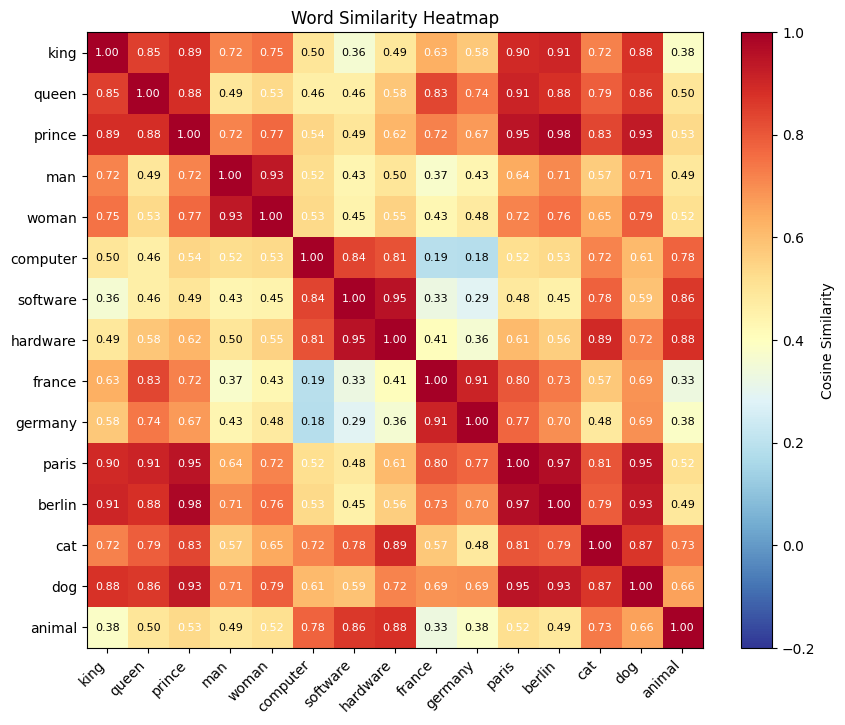

In [60]:
plot_similarity_heatmap(emb, vocab)

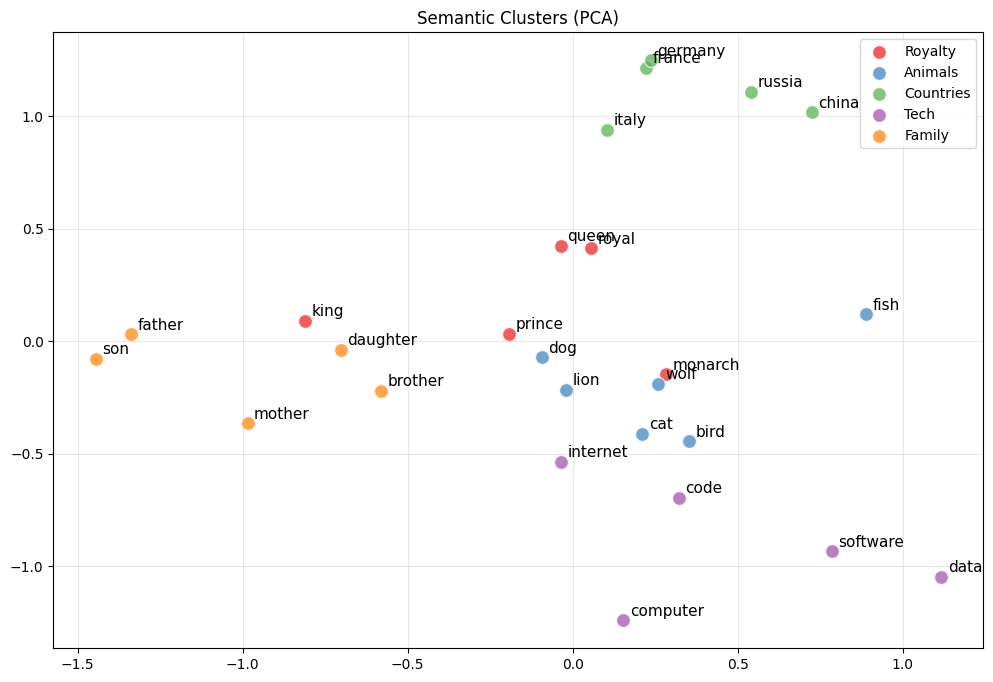

In [61]:
plot_semantic_clusters(emb, vocab)

In [39]:
import pickle

word_vectors = model.W_in
np.save("my_word2vec_embeddings.npy", word_vectors)
np.savez("word2vec_weights.npz", W_in=model.W_in, W_out=model.W_out)
np.savez("model.npz", model)
vocab_data = {
    'word2idx': vocab.word2idx,
    'idx2word': vocab.idx2word
}
with open("word2vec_vocab.pkl", "wb") as f:
    pickle.dump(vocab_data, f)

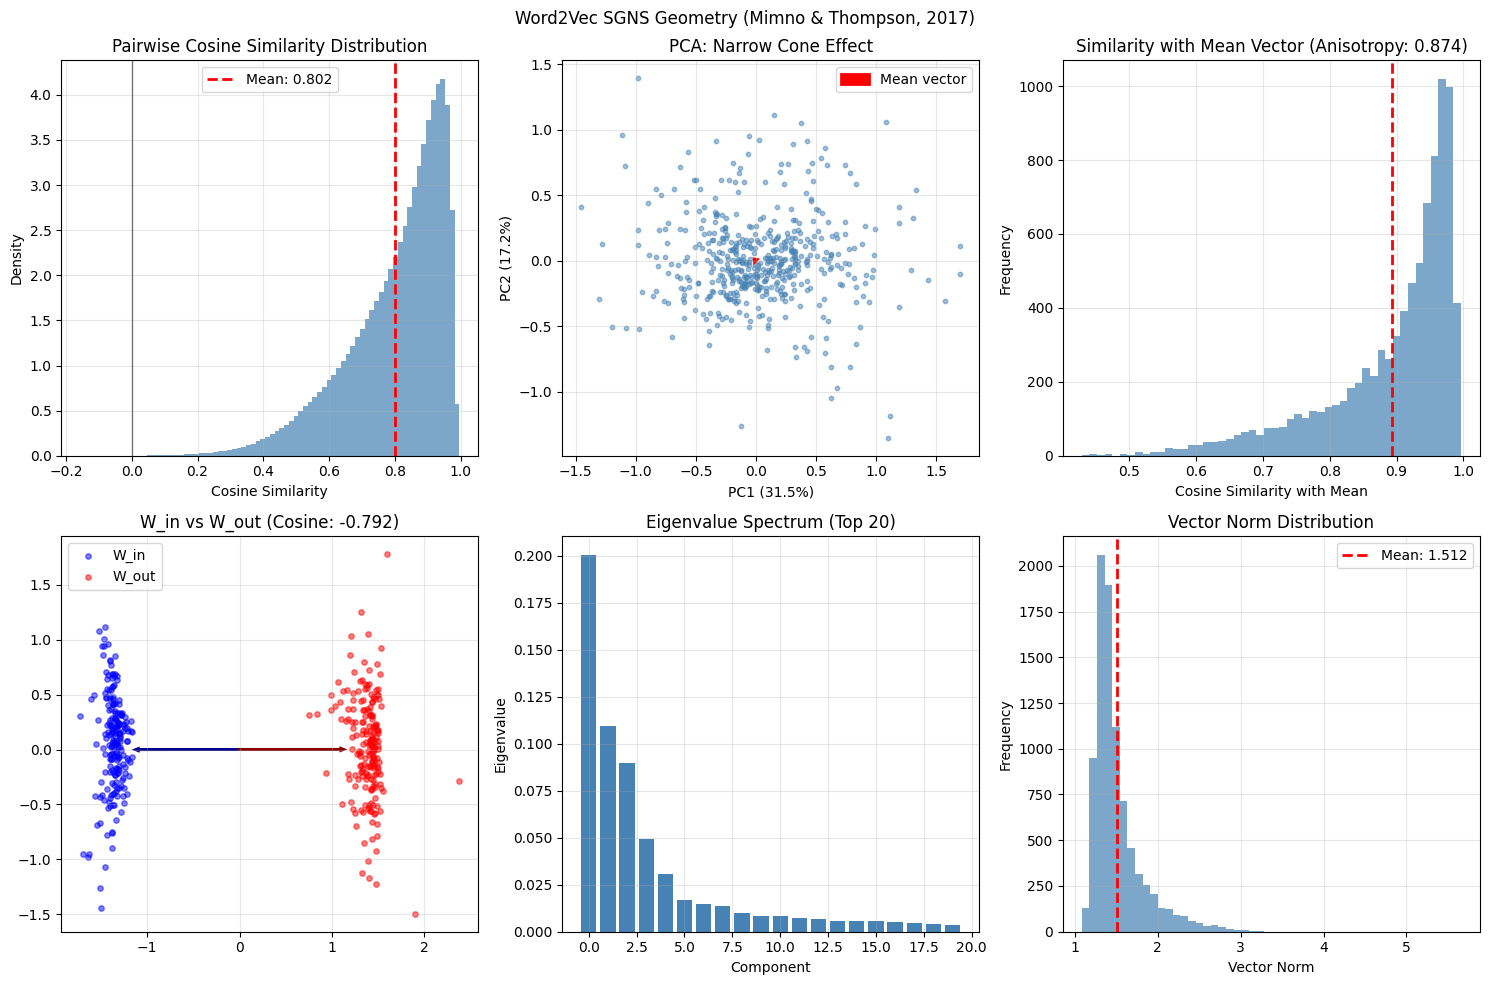

In [58]:
W_in, W_out = model.W_in, model.W_out

n = W_in.shape[0]

# Pairwise cosine similarities
sample_size = min(3000, n)
indices = np.random.choice(n, sample_size, replace=False)
norms = np.linalg.norm(W_in[indices], axis=1, keepdims=True)
normalized = W_in[indices] / (norms + 1e-10)
sim_matrix = normalized @ normalized.T
pairwise_sims = sim_matrix[np.triu_indices(sample_size, k=1)]
mean_sim = pairwise_sims.mean()

# Mean vector analysis
mean_vec = W_in.mean(axis=0)
mean_norm = np.linalg.norm(mean_vec)
avg_norm = np.linalg.norm(W_in, axis=1).mean()
anisotropy = mean_norm / avg_norm

# Cosine with mean
normalized_all = W_in / (np.linalg.norm(W_in, axis=1, keepdims=True) + 1e-10)
mean_normalized = mean_vec / (mean_norm + 1e-10)
cosines_with_mean = normalized_all @ mean_normalized

# ===== PLOTS =====
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Pairwise cosine distribution
ax = axes[0, 0]
ax.hist(pairwise_sims, bins=80, density=True, alpha=0.7, color='steelblue')
ax.axvline(mean_sim, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_sim:.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title('Pairwise Cosine Similarity Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. PCA narrow cone
ax = axes[0, 1]
sample_idx = np.random.choice(len(pca_2d), min(500, len(pca_2d)), replace=False)
ax.scatter(pca_2d[sample_idx, 0], pca_2d[sample_idx, 1], alpha=0.5, s=10, c='steelblue')
mean_2d = pca_2d.mean(axis=0)
ax.arrow(0, 0, mean_2d[0], mean_2d[1], head_width=0.03, head_length=0.02,
          fc='red', ec='red', linewidth=2, label='Mean vector')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA: Narrow Cone Effect')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Similarity with mean vector
ax = axes[0, 2]
ax.hist(cosines_with_mean, bins=50, color='steelblue', alpha=0.7)
ax.axvline(cosines_with_mean.mean(), color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Cosine Similarity with Mean')
ax.set_ylabel('Frequency')
ax.set_title(f'Similarity with Mean Vector (Anisotropy: {anisotropy:.3f})')
ax.grid(True, alpha=0.3)

# 4. W_in vs W_out
ax = axes[1, 0]
if W_out is not None:
    combined = np.vstack([W_in, W_out])
    combined_centered = combined - combined.mean(axis=0)
    combined_cov = (combined_centered.T @ combined_centered) / len(combined_centered)
    combined_evec = np.linalg.eigh(combined_cov)[1][:, ::-1]
    combined_pca = combined_centered @ combined_evec[:, :2]

    pca_in = combined_pca[:len(W_in)]
    pca_out = combined_pca[len(W_in):]

    si = np.random.choice(len(pca_in), min(200, len(pca_in)), replace=False)
    so = np.random.choice(len(pca_out), min(200, len(pca_out)), replace=False)

    ax.scatter(pca_in[si, 0], pca_in[si, 1], alpha=0.5, s=15, c='blue', label='W_in')
    ax.scatter(pca_out[so, 0], pca_out[so, 1], alpha=0.5, s=15, c='red', label='W_out')

    mi, mo = pca_in.mean(axis=0), pca_out.mean(axis=0)
    ax.arrow(0, 0, mi[0]*0.8, mi[1]*0.8, head_width=0.02, fc='darkblue', ec='darkblue', linewidth=2)
    ax.arrow(0, 0, mo[0]*0.8, mo[1]*0.8, head_width=0.02, fc='darkred', ec='darkred', linewidth=2)
    ax.set_title(f'W_in vs W_out (Cosine: {cos_means:.3f})')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'W_out unavailable', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('W_in vs W_out')
ax.grid(True, alpha=0.3)

# 5. Eigenvalue spectrum
ax = axes[1, 1]
ax.bar(range(min(20, len(eigenvalues))), eigenvalues[:20], color='steelblue')
ax.set_xlabel('Component')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalue Spectrum (Top 20)')
ax.grid(True, alpha=0.3)

# 6. Vector norms
ax = axes[1, 2]
norms_all = np.linalg.norm(W_in, axis=1)
ax.hist(norms_all, bins=50, color='steelblue', alpha=0.7)
ax.axvline(avg_norm, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_norm:.3f}')
ax.set_xlabel('Vector Norm')
ax.set_ylabel('Frequency')
ax.set_title('Vector Norm Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Word2Vec SGNS Geometry (Mimno & Thompson, 2017)', fontsize=12)
plt.tight_layout()

plt.show()

In [59]:
print({'mean_pairwise_sim': mean_sim, 'anisotropy': anisotropy, 'pc1_var': explained[0]})

{'mean_pairwise_sim': np.float64(0.8017836987674233), 'anisotropy': np.float64(0.8740535556998552), 'pc1_var': np.float64(0.3149855838446291)}


Let's try subtracting the average vector to cancel out the effect of the vectors being in the same direction.

In [54]:
W_corrected = W_in - W_in.mean(axis=0)

emb_corrected = W_corrected

# Test Similarity
most_similar("king", emb_corrected, vocab)
most_similar("computer", emb_corrected, vocab)

# Test Analogies
analogy("man", "king", "woman", emb_corrected, vocab)
analogy("paris", "france", "berlin", emb_corrected, vocab)
analogy("good", "better", "bad", emb_corrected, vocab)

Nearest to 'king':
  king            1.0000
  philip          0.9167
  johnston        0.8997
  nathaniel       0.8954
  olympias        0.8951
  pope            0.8942
  attila          0.8813
  howe            0.8773
  aldous          0.8743
  branden         0.8741

Nearest to 'computer':
  computer        1.0000
  animation       0.8563
  poetry          0.7870
  video           0.7863
  newton          0.7652
  killer          0.7389
  apple           0.7358
  objectivism     0.7263
  science         0.7233
  anime           0.7155

man:king :: woman:burgoyne (0.8373)
paris:france :: berlin:spain (0.8558)
good:better :: bad:independently (0.6433)


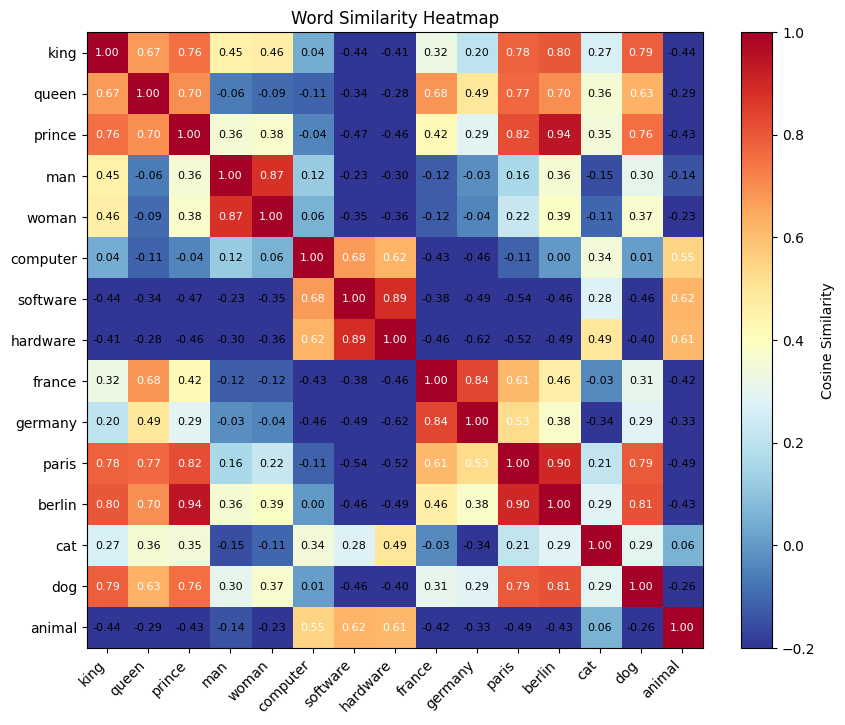

In [56]:
plot_similarity_heatmap(emb_corrected, vocab)

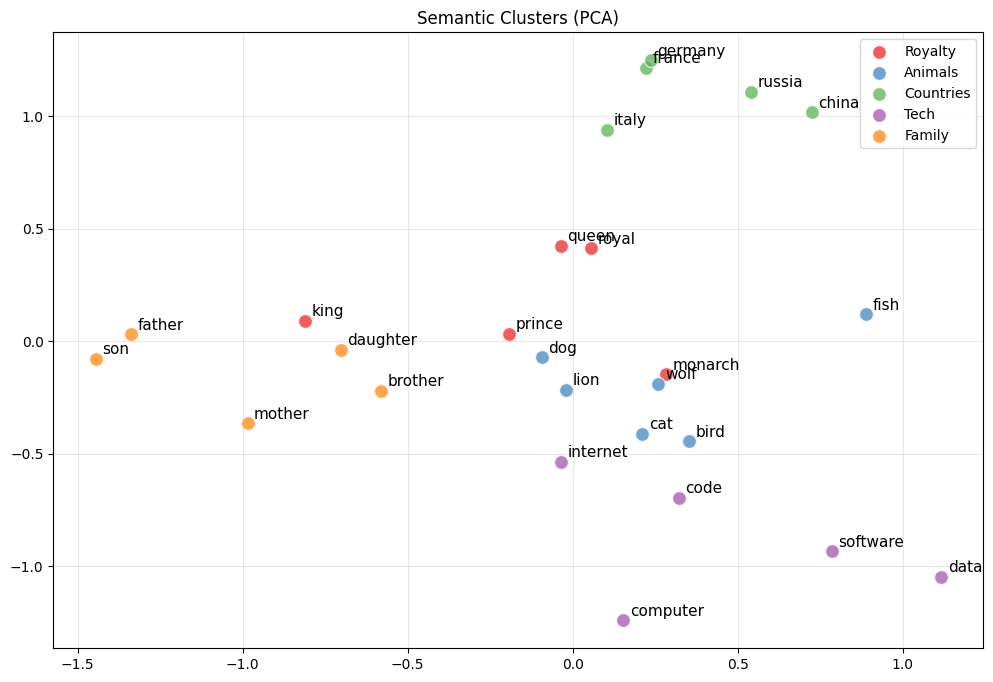

In [57]:
plot_semantic_clusters(emb_corrected, vocab)
